# Double ML

## Case Study: Personalized Hypertension Treatment

A clinical trial is conducted with 10,000 patients to assess the effectiveness of a new medication for lowering blood pressure. Researchers collect five patient characteristics: Blood Pressure (BP), BMI, Physical Activity, and Cholesterol.

**Treatment Assignment**

The probability of receiving the new drug depends on baseline blood pressure, BMI, and cholesterol:
$$
\text{logit} = 0.05 \times \text{BP} - 0.02 \times \text{BMI} + 0.01 \times \text{Cholesterol} - 0.2
$$

Patients with higher blood pressure and cholesterol are more likely to be prescribed the medication.

**Baseline**

The baseline blood pressure after lifestyle adjustments is influenced by BP, BMI, age, and cholesterol:
$$
\text{Baseline BP} = 1.0 \times \text{Baseline} - 1.2 \times \text{BMI} + 0.7 \times \text{Age} + 0.3 \times \text{Cholesterol} 
+ 0.5 \times \text{Physical Activity}
$$


**True Treatment Effect**

The drug’s effect is **heterogeneous** and depends on baseline blood pressure:
$$
\tau_{\text{true}} = 1.0 + 0.1 \times \text{Baseline BP}
$$

Patients with higher initial blood pressure experience a stronger reduction.

## Data Generation

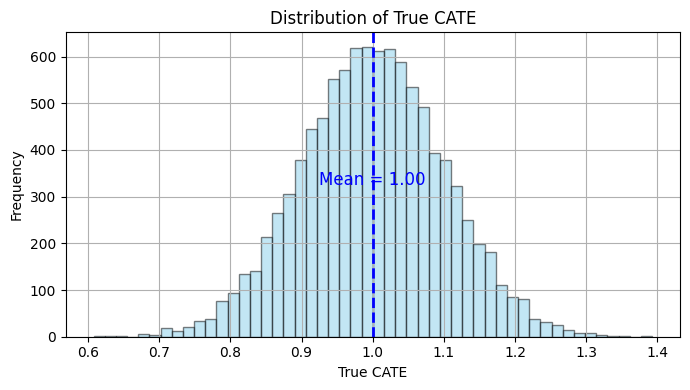

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# -----------------------------
# Step 1: Simulate medication scenario 
# -----------------------------
rng = np.random.RandomState(42)
n = 10000

# Features
Baseline_BP = rng.normal(size=n)
BMI = rng.normal(size=n)
Age = rng.normal(size=n)
Physical_Activity = rng.normal(size=n)
Cholesterol = rng.normal(size=n)

# Treatment assignment probability
logit = 0.05*Baseline_BP - 0.02*BMI + 0.01*Cholesterol - 0.2
p_T = 1 / (1 + np.exp(-logit))
Treatment = rng.binomial(1, p_T, size=n)

# Baseline outcome
baseline = 1.0*Baseline_BP - 1.2*BMI + 0.7*Age + 0.3*Cholesterol + 0.5*Physical_Activity

# True heterogeneous treatment effect
tau_true = 1.0 + 0.1*Baseline_BP

# Outcome with noise
Outcome = baseline + tau_true*Treatment + rng.normal(scale=1.0, size=n)

# Create DataFrame
data = pd.DataFrame({
    "Baseline_BP": Baseline_BP,
    "BMI": BMI,
    "Age": Age,
    "Physical_Activity": Physical_Activity,
    "Cholesterol": Cholesterol,
    "Treatment": Treatment,
    "Outcome": Outcome,
    "True_CATE": tau_true
})

# -----------------------------
# Plot histogram of True_CATE
# -----------------------------
mean_cate = data['True_CATE'].mean()

plt.figure(figsize=(7, 4))
data['True_CATE'].hist(bins=50, color='skyblue', edgecolor='black', alpha=0.5)
plt.axvline(mean_cate, color='blue', linestyle='--', linewidth=2)
plt.text(mean_cate, plt.ylim()[1]*0.5, f"Mean = {mean_cate:.2f}", color='blue', ha='center',fontsize=12)
plt.title("Distribution of True CATE")
plt.xlabel("True CATE")
plt.ylabel("Frequency")
plt.tight_layout()

In [10]:
from sklearn.model_selection import train_test_split
covariates = ["Baseline_BP", "BMI", "Age", "Physical_Activity", "Cholesterol"]

# Step 1: Split the data
train, test = train_test_split(data, test_size=0.3, random_state=42, stratify=Treatment)
X_train = train[covariates]
Y_train = train['Outcome']
T_train = train['Treatment']
X_test = test[covariates]
Y_test = test['Outcome']
T_test = test['Treatment']

## EconML

### 1. Linear DML
- Purpose: Estimates treatment effects assuming a linear relationship between treatment and outcome after residualization.
- Use case: When you want interpretability and coefficients for heterogeneity.

In [11]:
from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Step 2: Define nuisance models
model_y = RandomForestRegressor(n_estimators=200, random_state=1)
model_t = RandomForestClassifier(n_estimators=200, random_state=1)

# Step 3: Initialize LinearDML estimator
linear_dml = LinearDML(
    model_y=model_y,
    model_t=model_t,
    discrete_treatment=True,  # binary treatment
    random_state=42)

# Step 4: Fit the estimator
linear_dml.fit(Y_train, T_train, X = X_train)

# Step 5: Estimate ATE and CATE
linear_dml_ate = linear_dml.ate(X=X_test)
linear_dml_cate = linear_dml.effect(X=X_test)

true_ate = np.mean(test["True_CATE"])
print("Estimated ATE (EconML LinearDML):", round(linear_dml_ate, 4))
print("True ATE (from data):", round(true_ate, 4))

Estimated ATE (EconML LinearDML): 0.9979
True ATE (from data): 1.0013


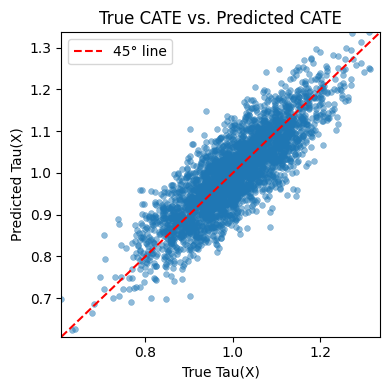

In [12]:
# Scatter plot
def scatter_plot(true_tau, pred_tau):
    plt.figure(figsize=(4,4))
    sns.scatterplot(x=true_tau, y=pred_tau, s=18, alpha=0.5, edgecolor=None)
    lims = [min(true_tau.min(), pred_tau.min()), max(true_tau.max(), pred_tau.max())]
    plt.plot(lims, lims, 'r--', lw=1.5, label='45° line')
    plt.xlim(lims); plt.ylim(lims)
    plt.xlabel('True Tau(X)')
    plt.ylabel('Predicted Tau(X)')
    plt.title('True CATE vs. Predicted CATE')
    plt.legend()
    plt.tight_layout()
    plt.show()
scatter_plot(true_tau = test['True_CATE'], pred_tau = linear_dml_cate)

### 2. Flexible DML
- Purpose: Flexible DML where you can specify any final stage model (e.g., Lasso, Ridge).
- Use case: When you want regularization in the final stage.

Estimated ATE (EconML LinearDML): 0.947
True ATE (from data): 1.0013


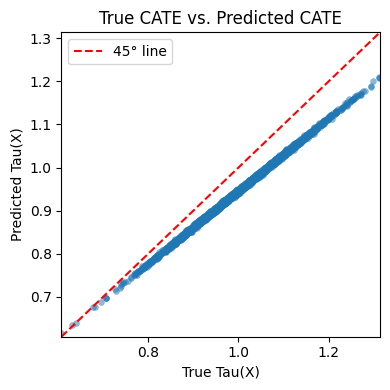

In [13]:
from econml.dml import DML
from sklearn.linear_model import LassoCV
from sklearn.ensemble import GradientBoostingRegressor

flexible_dml = DML(
    model_y=GradientBoostingRegressor(),
    model_t=GradientBoostingRegressor(),
    model_final=LassoCV(fit_intercept=False),
)
flexible_dml.fit(Y_train, T_train, X=X_train)

# Step 5: Estimate ATE and CATE
flexible_dml_ate = flexible_dml.ate(X=X_test)
flexible_dml_cate = flexible_dml.effect(X=X_test)

print("Estimated ATE (EconML LinearDML):", round(flexible_dml_ate, 4))
print("True ATE (from data):", round(true_ate, 4))
scatter_plot(true_tau = test['True_CATE'], pred_tau = flexible_dml_cate)

### 3. SparseLinearDML

- Purpose: Like LinearDML but uses Lasso for sparsity in heterogeneity terms.
- Use case: High-dimensional covariates where feature selection matters.

Estimated ATE (EconML LinearDML): 0.985
True ATE (from data): 1.0013


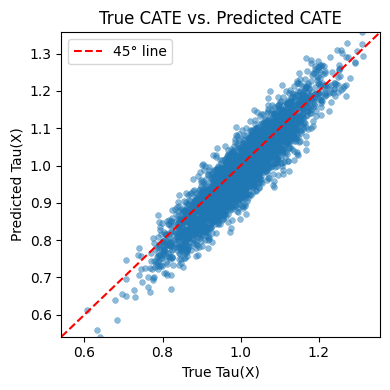

In [14]:
from econml.dml import SparseLinearDML
from sklearn.linear_model import LassoCV
from sklearn.ensemble import GradientBoostingRegressor

sparse_linear_dml = SparseLinearDML(discrete_treatment=True)
sparse_linear_dml.fit(Y_train, T_train, X=X_train)

# Step 5: Estimate ATE and CATE
sparse_linear_dml_ate = sparse_linear_dml.ate(X=X_test)
sparse_linear_dml_cate = sparse_linear_dml.effect(X=X_test)

print("Estimated ATE (EconML LinearDML):", round(sparse_linear_dml_ate, 4))
print("True ATE (from data):", round(true_ate, 4))
scatter_plot(true_tau = test['True_CATE'], pred_tau = sparse_linear_dml_cate)

### 4. NonParamDML

- Purpose: Fully nonparametric estimation using ML models for both nuisance and final stage.
- Use case: When you want flexible modeling without assuming linearity.

Estimated ATE (EconML LinearDML): 0.9777
True ATE (from data): 1.0013


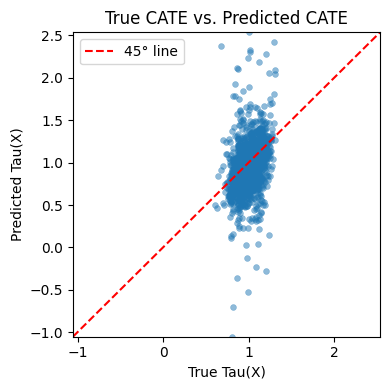

In [15]:
from econml.dml import NonParamDML
from sklearn.ensemble import GradientBoostingRegressor

non_param_dml = NonParamDML(
    model_y=GradientBoostingRegressor(),
    model_t=GradientBoostingRegressor(),
    model_final=GradientBoostingRegressor())
non_param_dml.fit(Y_train, T_train, X=X_train)

# Step 5: Estimate ATE and CATE
non_param_dml_ate = non_param_dml.ate(X=X_test)
non_param_dml_cate = non_param_dml.effect(X=X_test)

print("Estimated ATE (EconML LinearDML):", round(non_param_dml_ate, 4))
print("True ATE (from data):", round(true_ate, 4)) 
scatter_plot(true_tau = test['True_CATE'], pred_tau = non_param_dml_cate)

### 5. CausalForestDML

- Purpose: Uses causal forests for heterogeneous treatment effects.
- Use case: When you want individual-level CATE estimates and confidence intervals.

/opt/anaconda3/envs/book_ci/lib/python3.12/site-packages/econml/dml/dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)
/opt/anaconda3/envs/book_ci/lib/python3.12/site-packages/econml/dml/dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)


Estimated ATE (EconML LinearDML): 0.9859
True ATE (from data): 1.0013


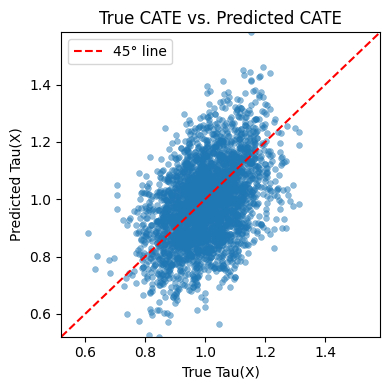

In [17]:
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor

causal_forest_dml = CausalForestDML(
    model_y=GradientBoostingRegressor(),
    model_t=GradientBoostingRegressor(),
    discrete_treatment=True,
    random_state=42
)
causal_forest_dml.fit(Y_train, T_train, X=X_train)

# Step 5: Estimate ATE and CATE
causal_forest_dml_ate = causal_forest_dml.ate(X=X_test)
causal_forest_dml_cate = causal_forest_dml.effect(X=X_test)

print("Estimated ATE (EconML LinearDML):", round(causal_forest_dml_ate, 4))
print("True ATE (from data):", round(true_ate, 4)) 
scatter_plot(true_tau = test['True_CATE'], pred_tau = causal_forest_dml_cate)